In [31]:
import sys
import os

import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

sys.path.append('../../official_github')
from dataset.mnist import load_mnist
from my_models import *

In [ ]:
(x_train, t_train), (x_test, t_test) = load_mnist(False, False)

In [33]:
def normalize(data: np.ndarray, mean: int=None, std: int=None) -> np.ndarray:
    if mean == None:
        mean = np.mean(data)
        
    if std == None:
        std = np.std(data)
    
    data = (data - mean) / std
    return data

In [1]:
x_train = normalize(x_train)
x_test = normalize(x_test)

print(x_train.shape)
print(np.max(x_train))
print(t_train.shape)

NameError: name 'normalize' is not defined

In [35]:
print(x_train.shape)
print(np.max(x_train))
print(t_train.shape)

(50000, 32, 32, 3)
2.09341038199596
(50000,)


In [36]:
network_dict = {
                'leaky-0.2': MultiLayerNetExtend(input_size=3*32*32, hidden_size_list=[100], output_size=10, activation='leaky', weight_init_std='relu', use_dropout=True, dropout_ration=0.2, weight_decay_lambda=0.1),
                'leaky-0.5': MultiLayerNetExtend(input_size=3*32*32, hidden_size_list=[100], output_size=10, activation='leaky', weight_init_std='relu', use_dropout=True, dropout_ration=0.5, weight_decay_lambda=0.1),
                'leaky-0.7': MultiLayerNetExtend(input_size=3*32*32, hidden_size_list=[100], output_size=10, activation='leaky', weight_init_std='relu', use_dropout=True, dropout_ration=0.7, weight_decay_lambda=0.1),
                }

In [37]:
# 하이퍼 파라메터
iters_num = 50_000  # 반복횟수
train_size = x_train.shape[0]
batch_size = 100  # 미니배치 크기
learning_rate = 0.1
iter_per_epoch = max(train_size / batch_size, 1)

In [38]:
output_dict = {}
for key, network in network_dict.items():

    # optimizer = SGD(lr=learning_rate)
    
    output_dict[f'{key} train acc'] = []
    output_dict[f'{key} test acc'] = []
    
    print(f'=== {key} network training start ===')
    for i in range(iters_num):
        # print(i)
        # 미니배치 획득
        batch_mask = np.random.choice(train_size, batch_size)
        x_batch = x_train[batch_mask]
        t_batch = t_train[batch_mask]

        # 오차역전파법으로 기울기 계산
        grad = network.gradient(x_batch, t_batch)

        # 매개변수 갱신
        for param in ('W1', 'b1', 'W2', 'b2'):
            network.params[param] -= learning_rate * grad[param]

        # 학습 경과 기록
        loss = network.loss(x_batch, t_batch)
        # print('loss:', loss)

        # 1에폭 당 정확도 계산
        if i % iter_per_epoch == 0:
            train_acc = network.accuracy(x_train, t_train)
            test_acc = network.accuracy(x_test, t_test)
            output_dict[f'{key} train acc'].append(train_acc)
            output_dict[f'{key} test acc'].append(test_acc)
            print(f'--- {key} result report ---')
            print("train acc, test acc | " + str(train_acc) + ", " + str(test_acc))
        
    print('='*10)
    print('\n\n')


=== leaky-0.2 network training start ===
--- leaky-0.2 result report ---
train acc, test acc | 0.18428, 0.1892
--- leaky-0.2 result report ---
train acc, test acc | 0.37092, 0.37
--- leaky-0.2 result report ---
train acc, test acc | 0.37414, 0.3696
--- leaky-0.2 result report ---
train acc, test acc | 0.37708, 0.374
--- leaky-0.2 result report ---
train acc, test acc | 0.36204, 0.3599
--- leaky-0.2 result report ---
train acc, test acc | 0.34882, 0.3389
--- leaky-0.2 result report ---
train acc, test acc | 0.34772, 0.3473
--- leaky-0.2 result report ---
train acc, test acc | 0.39966, 0.3885
--- leaky-0.2 result report ---
train acc, test acc | 0.37034, 0.3661
--- leaky-0.2 result report ---
train acc, test acc | 0.37752, 0.3781
--- leaky-0.2 result report ---
train acc, test acc | 0.3664, 0.3637
--- leaky-0.2 result report ---
train acc, test acc | 0.38346, 0.379
--- leaky-0.2 result report ---
train acc, test acc | 0.37868, 0.3825
--- leaky-0.2 result report ---
train acc, test acc | 

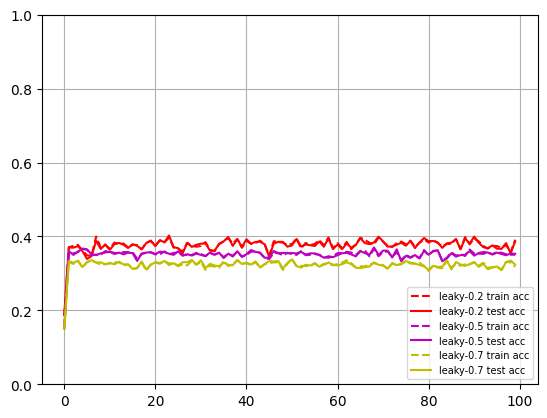

In [39]:
for k, v in output_dict.items():
    
    x = range(len(v))
    
    if '0.7' in k:
        color_code = 'y'
    elif '0.2' in k:
        color_code = 'r'
    elif '0.5' in k:
        color_code = 'm'
    # elif k.startswith('relu'):
        # color_code = 'b'
    # elif k.startswith('leaky'):
        # color_code = 'c'

    if 'train' in k:
        linestyle = 'dashed'
    else:
        linestyle = 'solid'
    
    plt.plot(x, v, linestyle=linestyle, color=color_code, label = k)
        
plt.ylim([0.0, 1.0])
plt.legend(loc='lower right', prop={'size':7})
plt.grid()